In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

df = pd.read_csv('Research Data - Summary.csv')

# Function to extract mean and std from strings like "0.7746 (±0.0129)"
def extract_mean_std(value):
    if pd.isna(value) or isinstance(value, float):
        return value, 0
    match = re.match(r"([\d.]+)\s*\(±([\d.]+)\)", str(value))
    if match:
        return float(match.group(1)), float(match.group(2))
    return float(value), 0

# Apply extraction to relevant columns
for col in ['Accuracy', 'F1', 'Epochs']:
    df[[f'{col}_mean', f'{col}_std']] = df[col].apply(
        lambda x: pd.Series(extract_mean_std(x))
    )

# Convert categorical columns to appropriate types
df['Base_Model_Class'] = pd.to_numeric(df['Base_Model_Class'], errors='coerce')
df['FT/Direct_Classes'] = pd.to_numeric(df['FT/Direct_Classes'], errors='coerce')
df['FT/T_Instance_per_class'] = pd.to_numeric(df['FT/T_Instance_per_class'], errors='coerce')

/tmp/ipykernel_19846/3449818680.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Model_Instance'] = filtered_df.apply(


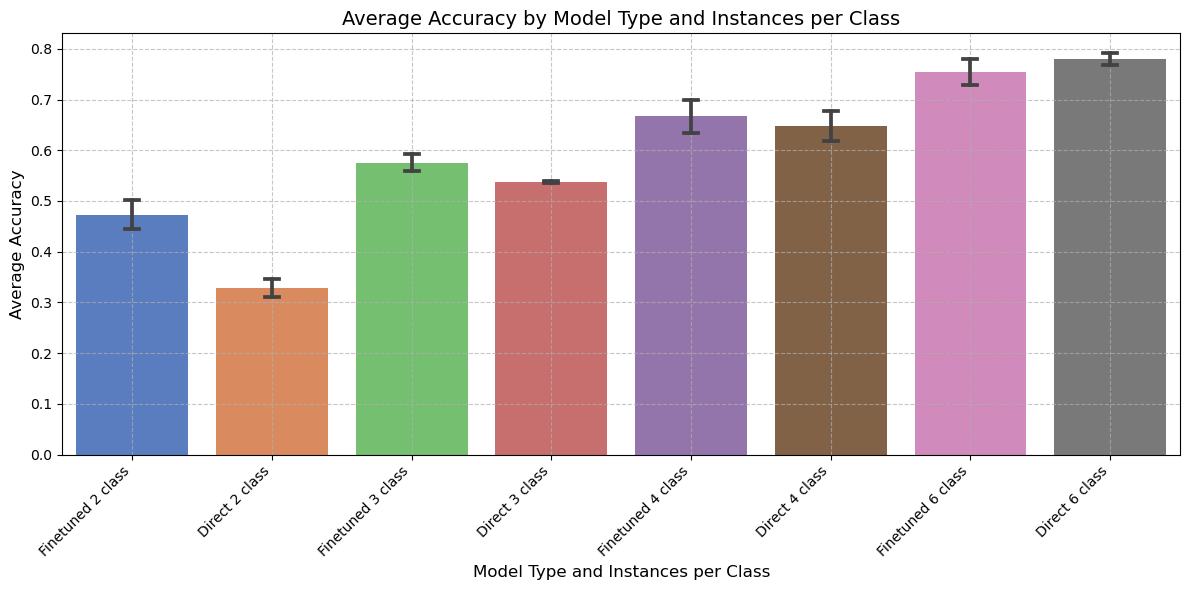

In [18]:
# Filter the dataframe to include only finetuned and direct models
filtered_df = df[df['Model_Type'].isin(['FINETUNED', 'DIRECT'])]

# Create a new column for the x-axis categories
filtered_df['Model_Instance'] = filtered_df.apply(
    lambda row: f"{row['Model_Type'].capitalize()} {int(row['FT/T_Instance_per_class'])} class",
    axis=1
)

# Define the order of the categories for the x-axis
category_order = [
    'Finetuned 2 class', 'Direct 2 class', 'Finetuned 3 class', 'Direct 3 class', 'Finetuned 4 class', 'Direct 4 class', 'Finetuned 6 class',
       'Direct 6 class'
]

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=filtered_df,
    x='Model_Instance',
    y='Accuracy_mean',
    errorbar='sd',  # Error bars show the standard deviation of Accuracy_mean
    capsize=0.1,    # Add caps to the error bars for clarity
    palette='muted', # Use a muted color palette for better visualization
    order=category_order  # Ensure the x-axis categories are in the desired order
)

# Customize the plot
plt.title('Average Accuracy by Model Type and Instances per Class', fontsize=14)
plt.xlabel('Model Type and Instances per Class', fontsize=12)
plt.ylabel('Average Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)  # Add a grid for readability
plt.tight_layout()

# Display the plot
plt.show()

/tmp/ipykernel_19846/3526225032.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Model_Instance'] = filtered_df.apply(


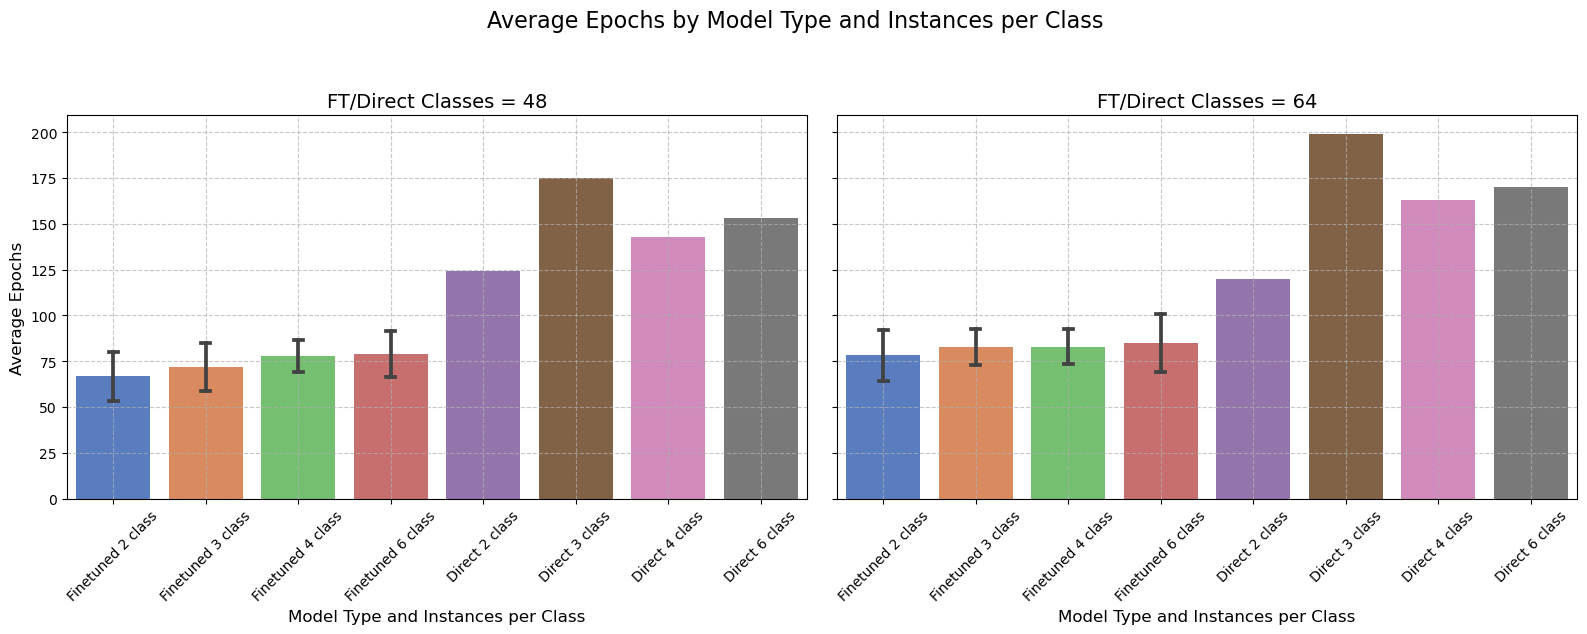

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataframe to include only finetuned and direct models
filtered_df = df[df['Model_Type'].isin(['FINETUNED', 'DIRECT'])]

# Create a new column for the x-axis categories
filtered_df['Model_Instance'] = filtered_df.apply(
    lambda row: f"{row['Model_Type'].capitalize()} {int(row['FT/T_Instance_per_class'])} class",
    axis=1
)

# Define the order of the categories for the x-axis
category_order = [
    'Finetuned 2 class', 'Finetuned 3 class', 'Finetuned 4 class', 'Finetuned 6 class',
    'Direct 2 class', 'Direct 3 class', 'Direct 4 class', 'Direct 6 class'
]

# Split the data into two subsets: one for FT/Direct_Classes == 48 and one for 64
df_48 = filtered_df[filtered_df['FT/Direct_Classes'] == 48]
df_64 = filtered_df[filtered_df['FT/Direct_Classes'] == 64]

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot for FT/Direct_Classes == 48
sns.barplot(
    data=df_48,
    x='Model_Instance',
    y='Epochs_mean',
    errorbar='sd',  # Error bars show the standard deviation of Epochs_mean
    capsize=0.1,    # Add caps to the error bars for clarity
    palette='muted', # Use a muted color palette for better visualization
    order=category_order,  # Ensure the x-axis categories are in the desired order
    ax=ax1
)
ax1.set_title('FT/Direct Classes = 48', fontsize=14)
ax1.set_xlabel('Model Type and Instances per Class', fontsize=12)
ax1.set_ylabel('Average Epochs', fontsize=12)
ax1.tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability
ax1.grid(True, linestyle='--', alpha=0.7)  # Add a grid for readability

# Plot for FT/Direct_Classes == 64
sns.barplot(
    data=df_64,
    x='Model_Instance',
    y='Epochs_mean',
    errorbar='sd',  # Error bars show the standard deviation of Epochs_mean
    capsize=0.1,    # Add caps to the error bars for clarity
    palette='muted', # Use a muted color palette for better visualization
    order=category_order,  # Ensure the x-axis categories are in the desired order
    ax=ax2
)
ax2.set_title('FT/Direct Classes = 64', fontsize=14)
ax2.set_xlabel('Model Type and Instances per Class', fontsize=12)
ax2.set_ylabel('')  # No y-label on the second plot since it's shared
ax2.tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability
ax2.grid(True, linestyle='--', alpha=0.7)  # Add a grid for readability

# Adjust layout to prevent overlap
plt.suptitle('Average Epochs by Model Type and Instances per Class', fontsize=16, y=1.05)
plt.tight_layout()

# Display the plot
plt.show()

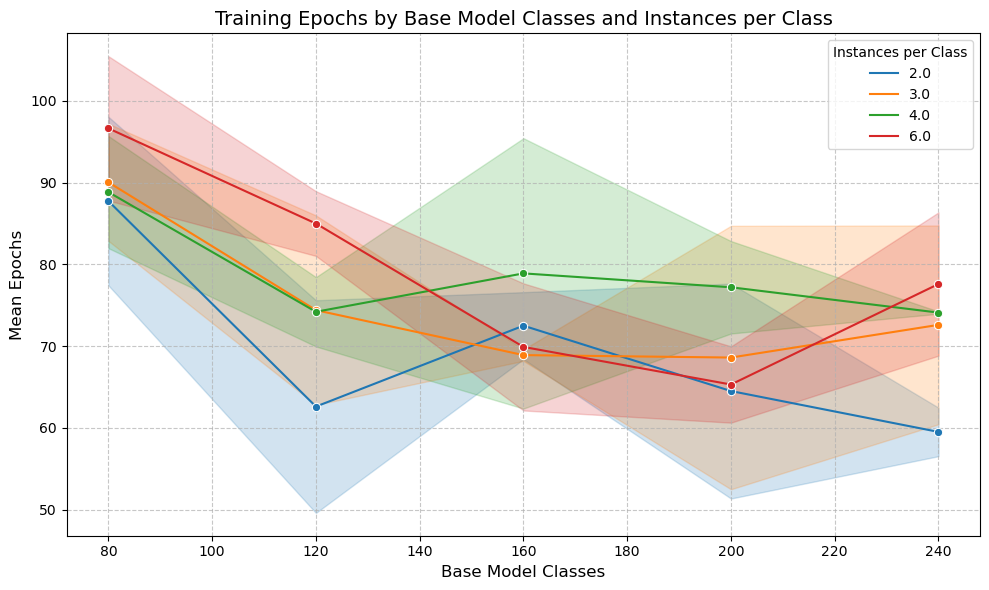

In [22]:
ft_data = df[df['Model_Type'] == 'FINETUNED']
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=ft_data,
    x='Base_Model_Class',
    y='Epochs_mean',
    hue='FT/T_Instance_per_class',
    marker='o',
    palette='tab10',
    errorbar='sd'
)
plt.title('Training Epochs by Base Model Classes and Instances per Class', fontsize=14)
plt.xlabel('Base Model Classes', fontsize=12)
plt.ylabel('Mean Epochs', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Instances per Class', loc='upper right')
plt.tight_layout()
plt.show()